# Week 3 — Python & Data Wrangling

This notebook covers the Week 3 assignment: Python/Pandas basics, cleaning a messy
dataset (missing values, wrong formats, duplicates), creating new columns, and
visualizing the results with Matplotlib and Seaborn.

**Dataset:** a fitness-tracker log (`raw_data.csv`) with 32 rows recording daily
exercise `Duration`, `Date`, `Pulse`, `Maxpulse`, and `Calories` burned.


## 1. Imports & loading the raw data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("raw_data.csv")
df.head(10)


   Duration          Date  Pulse  Maxpulse  Calories
0        60  '2020/12/01'    110       130     409.1
1        60  '2020/12/02'    117       145     479.0
2        60  '2020/12/03'    103       135     340.0
3        45  '2020/12/04'    109       175     282.4
4        45  '2020/12/05'    117       148     406.0
5        60  '2020/12/06'    102       127     300.0
6        60  '2020/12/07'    110       136     374.0
7       450  '2020/12/08'    104       134     253.3
8        30  '2020/12/09'    109       133     195.1
9        60  '2020/12/10'     98       124     269.0


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


## 2. Spotting the problems

A quick look at the raw data turns up several classic "messy data" issues:

- **`Date` is stored as text with stray quotes** (`'2020/12/01'`) instead of a real date.
- **One `Date` is missing** entirely (empty string).
- **One `Date` is in the wrong format** (`20201226` instead of `'2020/12/27'`).
- **Two `Calories` values are missing.**
- **One `Duration` looks like a typo** (`450` instead of `45`, an order of magnitude off from every other row).
- **One row is an exact duplicate** of another (both `2020/12/12`).

The cells below fix each of these in turn.


In [ ]:
# Strip stray quotes and standardize the one malformed date (20201226 -> 2020/12/27)
df["Date"] = df["Date"].astype(str).str.replace("'", "", regex=False)
df["Date"] = df["Date"].replace("20201226", "2020/12/26")
df["Date"] = df["Date"].replace({"nan": np.nan, "": np.nan})

# Convert to real datetimes
df["Date"] = pd.to_datetime(df["Date"], format="%Y/%m/%d", errors="coerce")
df[["Date"]].head()


        Date
0 2020-12-01
1 2020-12-02
2 2020-12-03
3 2020-12-04
4 2020-12-05


In [ ]:
# Missing Date: since the rows are in daily order, fill it in from its neighbours
missing_date_idx = df[df["Date"].isna()].index
for i in missing_date_idx:
    df.loc[i, "Date"] = df.loc[i - 1, "Date"] + pd.Timedelta(days=1)

df["Date"].isna().sum()  # should be 0


np.int64(0)


In [ ]:
# Fix the Duration outlier: 450 is almost certainly a typo for 45
df.loc[df["Duration"] > 300, "Duration"] = df.loc[df["Duration"] > 300, "Duration"] / 10
df["Duration"].describe()


count    32.000000
mean     55.781250
std       7.840072
min      30.000000
25%      56.250000
50%      60.000000
75%      60.000000
max      60.000000


In [ ]:
# Missing Calories: fill with the column mean (rounded to 1 decimal, matching the rest of the data)
mean_calories = round(df["Calories"].mean(), 1)
df["Calories"] = df["Calories"].fillna(mean_calories)
df["Calories"].isna().sum()  # should be 0


np.int64(0)


In [ ]:
# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row(s)")
df


Removed 1 duplicate row(s)
    Duration       Date  Pulse  Maxpulse  Calories
0         60 2020-12-01    110       130     409.1
1         60 2020-12-02    117       145     479.0
2         60 2020-12-03    103       135     340.0
3         45 2020-12-04    109       175     282.4
4         45 2020-12-05    117       148     406.0
5         60 2020-12-06    102       127     300.0
6         60 2020-12-07    110       136     374.0
7         45 2020-12-08    104       134     253.3
8         30 2020-12-09    109       133     195.1
9         60 2020-12-10     98       124     269.0
10        60 2020-12-11    103       147     329.3
11        60 2020-12-12    100       120     250.7
12        60 2020-12-13    106       128     345.3
13        60 2020-12-14    104       132     379.3
14        60 2020-12-15     98       123     275.0
15        60 2020-12-16     98       120     215.2
16        60 2020-12-17    100       120     300.0
17        45 2020-12-18     90       112     304.7
18  

## 3. Creating new columns

Two derived columns make the dataset more useful for analysis:

- **`Calories_per_Min`** — calories burned per minute of exercise (normalizes for session length).
- **`Pulse_Range`** — the gap between `Maxpulse` and `Pulse`, a rough measure of exertion.


In [ ]:
df["Calories_per_Min"] = (df["Calories"] / df["Duration"]).round(2)
df["Pulse_Range"] = df["Maxpulse"] - df["Pulse"]
df.head()


   Duration       Date  Pulse  Maxpulse  Calories  Calories_per_Min  Pulse_Range
0        60 2020-12-01    110       130     409.1              6.82           20
1        60 2020-12-02    117       145     479.0              7.98           28
2        60 2020-12-03    103       135     340.0              5.67           32
3        45 2020-12-04    109       175     282.4              6.28           66
4        45 2020-12-05    117       148     406.0              9.02           31


## 4. Filtering rows

A couple of example filters: high-intensity sessions and sessions that burned
more than 300 calories.


In [ ]:
high_intensity = df[df["Pulse"] > 110]
high_intensity


    Duration       Date  Pulse  Maxpulse  Calories  Calories_per_Min  Pulse_Range
1         60 2020-12-02    117       145     479.0              7.98           28
4         45 2020-12-05    117       148     406.0              9.02           31
22        60 2020-12-23    130       101     300.0              5.00          -29


In [ ]:
big_burn = df[df["Calories"] > 300]
big_burn[["Date", "Duration", "Calories", "Calories_per_Min"]]


         Date  Duration  Calories  Calories_per_Min
0  2020-12-01        60     409.1              6.82
1  2020-12-02        60     479.0              7.98
2  2020-12-03        60     340.0              5.67
4  2020-12-05        45     406.0              9.02
6  2020-12-07        60     374.0              6.23
10 2020-12-11        60     329.3              5.49
12 2020-12-13        60     345.3              5.76
13 2020-12-14        60     379.3              6.32
17 2020-12-18        45     304.7              6.77
18 2020-12-19        60     323.0              5.38
20 2020-12-21        60     364.2              6.07
24 2020-12-25        60     334.5              5.58
27 2020-12-28        60     304.7              5.08
29 2020-12-30        60     380.3              6.34


## 5. Visualizations

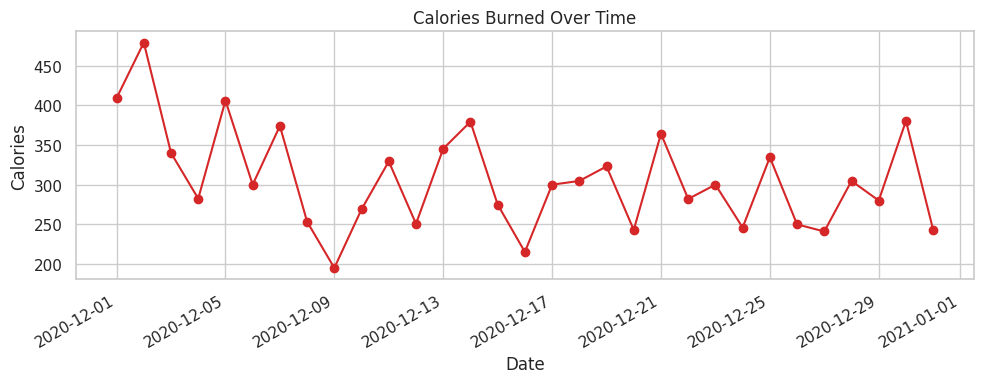

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["Date"], df["Calories"], marker="o", color="#d62728")
ax.set_title("Calories Burned Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Calories")
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("calories_over_time.png", dpi=150)
plt.show()


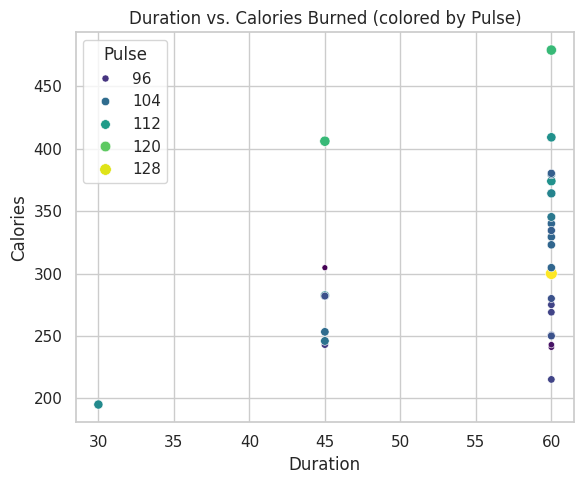

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="Duration", y="Calories", hue="Pulse", size="Pulse",
                 palette="viridis", ax=ax)
ax.set_title("Duration vs. Calories Burned (colored by Pulse)")
plt.tight_layout()
plt.savefig("duration_vs_calories.png", dpi=150)
plt.show()


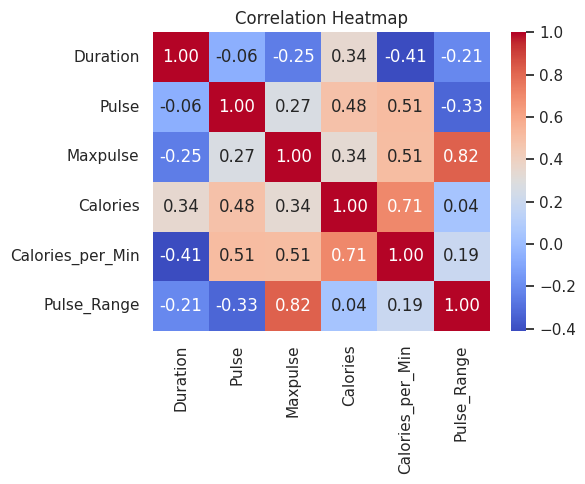

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[["Duration", "Pulse", "Maxpulse", "Calories", "Calories_per_Min", "Pulse_Range"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


## 6. Saving the cleaned dataset

In [ ]:
df.to_csv("cleaned_data.csv", index=False)
print("Saved cleaned_data.csv with", len(df), "rows and", len(df.columns), "columns")


Saved cleaned_data.csv with 31 rows and 7 columns


## Summary

- Fixed inconsistent date formats and filled one missing date by inferring it from
  the surrounding sequence.
- Corrected a `Duration` outlier (`450` → `45`) and filled missing `Calories`
  values with the column mean.
- Removed one exact duplicate row.
- Added `Calories_per_Min` and `Pulse_Range` as derived columns.
- Filtered the data for high-intensity and high-calorie-burn sessions.
- Visualized trends with a time-series line plot, a Duration-vs-Calories scatter
  plot, and a correlation heatmap.
